<a href="https://colab.research.google.com/github/cherryjl/IT480-FA26/blob/main/Assignments/Assignment%202/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *Logan Cherry*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: logancherry
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:09<00:00, 44.3MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [4]:
# Your exploration here
fire_path = os.path.join(data_dir_fire, 'fire_images')
non_fire_path = os.path.join(data_dir_fire, 'non_fire_images')

print(f"Fire images count: {len(os.listdir(fire_path))}")
print(f"Non-fire images count: {len(os.listdir(non_fire_path))}")

Fire images count: 755
Non-fire images count: 244


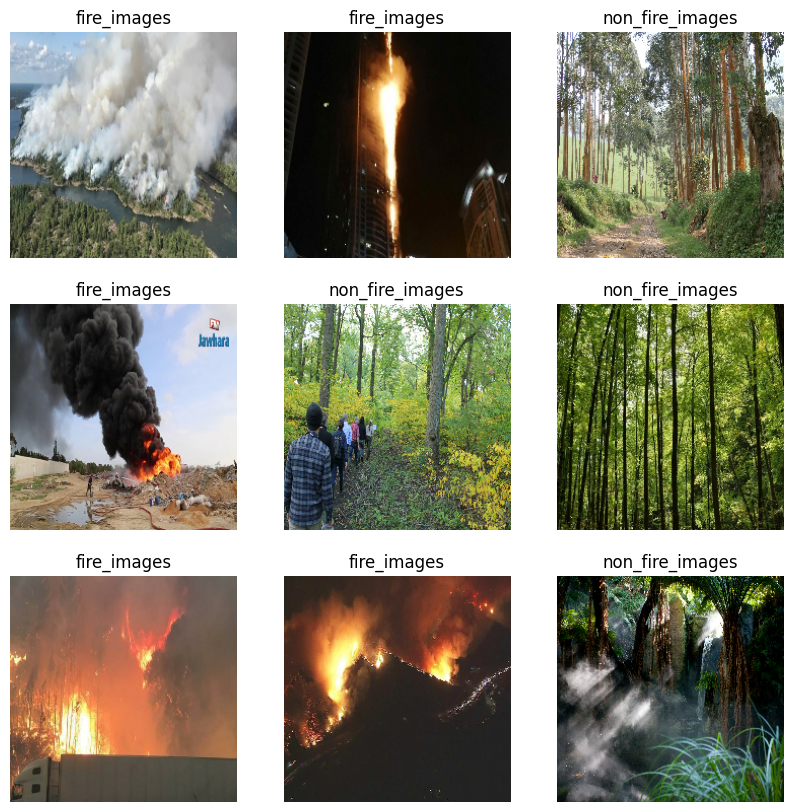

In [20]:
plt.figure(figsize=(10, 10))
for images, labels in train_raw_fire.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Convert the image tensor to an integer array for plotting
        plt.imshow(images[i].numpy().astype("uint8"))
        # Use the label index to get the actual class name
        plt.title(class_names_fire[labels[i]])
        plt.axis("off")

plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

There is significantly more fire images than non-fire ones, this could dramtically affect our training and testing of the model.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [5]:
# Preprocess the data here
def preprocess_data(image, label):
    return preprocess_input(image), label

train_ds_fire = train_raw_fire.map(preprocess_data)
val_ds_fire = val_raw_fire.map(preprocess_data)
test_ds_fire = test_raw_fire.map(preprocess_data)


In [6]:
# Build your model here
base_model_fire = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model_fire.trainable = False # Freeze the base

x = base_model_fire.output
x = GlobalAveragePooling2D()(x)

# Binary classification -> 1 output node with sigmoid
output_fire = Dense(1, activation='sigmoid')(x)

model_fire = Model(inputs=base_model_fire.input, outputs=output_fire)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
# Compile your model here

model_fire.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

## 1D — Train and Evaluate

In [8]:
# Train your model here
history_fire = model_fire.fit(train_ds_fire, validation_data=val_ds_fire, epochs=5)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8371 - loss: 0.3464 - val_accuracy: 0.9496 - val_loss: 0.1964
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9643 - loss: 0.1420 - val_accuracy: 0.9640 - val_loss: 0.1137
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.9771 - loss: 0.0966 - val_accuracy: 0.9640 - val_loss: 0.0866
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9829 - loss: 0.0785 - val_accuracy: 0.9784 - val_loss: 0.0741
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.9857 - loss: 0.0671 - val_accuracy: 0.9928 - val_loss: 0.0602


In [9]:
# Report validation and test accuracy here
test_loss_fire, test_acc_fire = model_fire.evaluate(test_ds_fire)
print(f"Test Accuracy: {test_acc_fire:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.9812 - loss: 0.0732
Test Accuracy: 0.9812


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

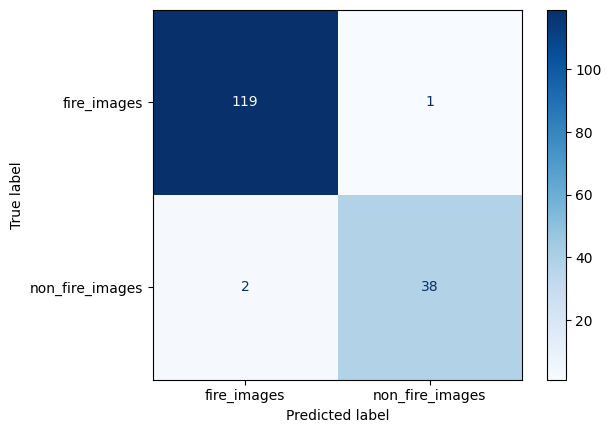

In [10]:
# Build your confusion matrix here
y_true_fire = []
y_pred_fire = []

for images, labels in test_ds_fire:
    preds = model_fire.predict(images, verbose=0)
    y_true_fire.extend(labels.numpy())
    y_pred_fire.extend((preds > 0.5).astype(int).flatten())

cm_fire = confusion_matrix(y_true_fire, y_pred_fire)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_fire, display_labels=class_names_fire)
disp.plot(cmap=plt.cm.Blues)
plt.show()


*Your answer:* A false negative is far more costly and dangerous than a false positive. I would think lowering the threshold would prevent/catch more real fires even if you get a few false alarms




---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [11]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q -o EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['SeaLake', 'HerbaceousVegetation', 'Forest', 'PermanentCrop', 'AnnualCrop', 'Industrial', 'Residential', 'Pasture', 'River', 'Highway']


In [12]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


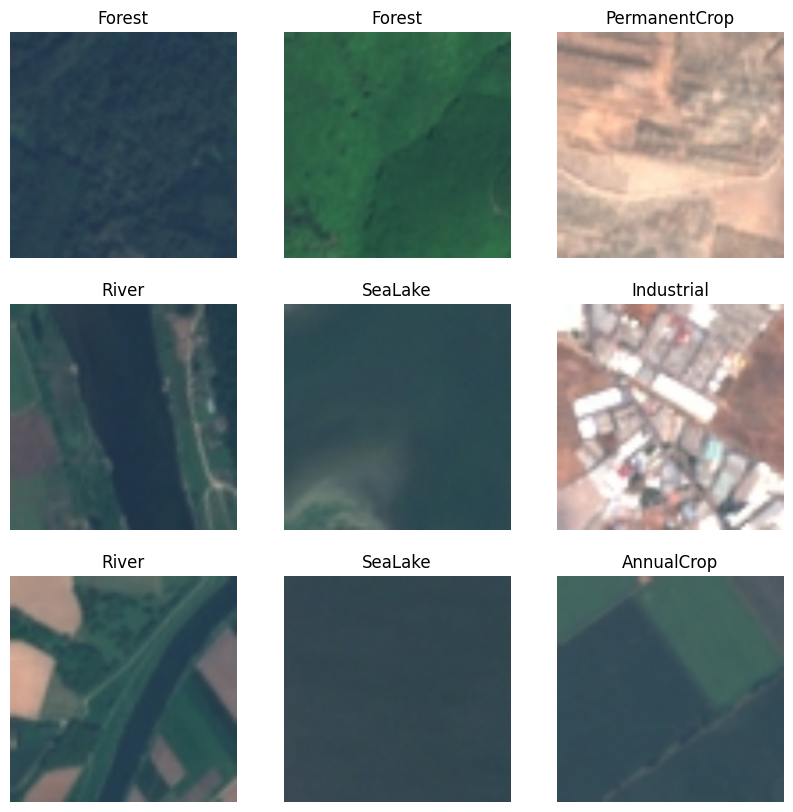

In [21]:
plt.figure(figsize=(10, 10))
for images, labels in train_raw_sat.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Convert the image tensor to an integer array for plotting
        plt.imshow(images[i].numpy().astype("uint8"))
        # Use the label index to get the actual class name
        plt.title(class_names_sat[labels[i]])
        plt.axis("off")

plt.show()

## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [13]:
# Preprocess the data here
train_ds_sat = train_raw_sat.map(preprocess_data)
val_ds_sat = val_raw_sat.map(preprocess_data)
test_ds_sat = test_raw_sat.map(preprocess_data)


In [14]:
# Build your model here
base_model_sat = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model_sat.trainable = False

x_sat = base_model_sat.output
x_sat = GlobalAveragePooling2D()(x_sat)

# Multi-class -> 10 output nodes with softmax
output_sat = Dense(10, activation='softmax')(x_sat)

model_sat = Model(inputs=base_model_sat.input, outputs=output_sat)

In [15]:
# Compile your model here
model_sat.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


## 2C — Train and Evaluate

In [16]:
# Train your model here
history_sat = model_sat.fit(train_ds_sat, validation_data=val_ds_sat, epochs=5)


Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.8822 - loss: 0.3639 - val_accuracy: 0.9294 - val_loss: 0.2157
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9360 - loss: 0.1936 - val_accuracy: 0.9383 - val_loss: 0.1896
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9481 - loss: 0.1580 - val_accuracy: 0.9381 - val_loss: 0.1879
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9544 - loss: 0.1378 - val_accuracy: 0.9420 - val_loss: 0.1821
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9593 - loss: 0.1212 - val_accuracy: 0.9398 - val_loss: 0.1787


In [17]:
# Report validation and test accuracy here
test_loss_sat, test_acc_sat = model_sat.evaluate(test_ds_sat)
print(f"Test Accuracy: {test_acc_sat:.4f}")


127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9385 - loss: 0.1760
Test Accuracy: 0.9385


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

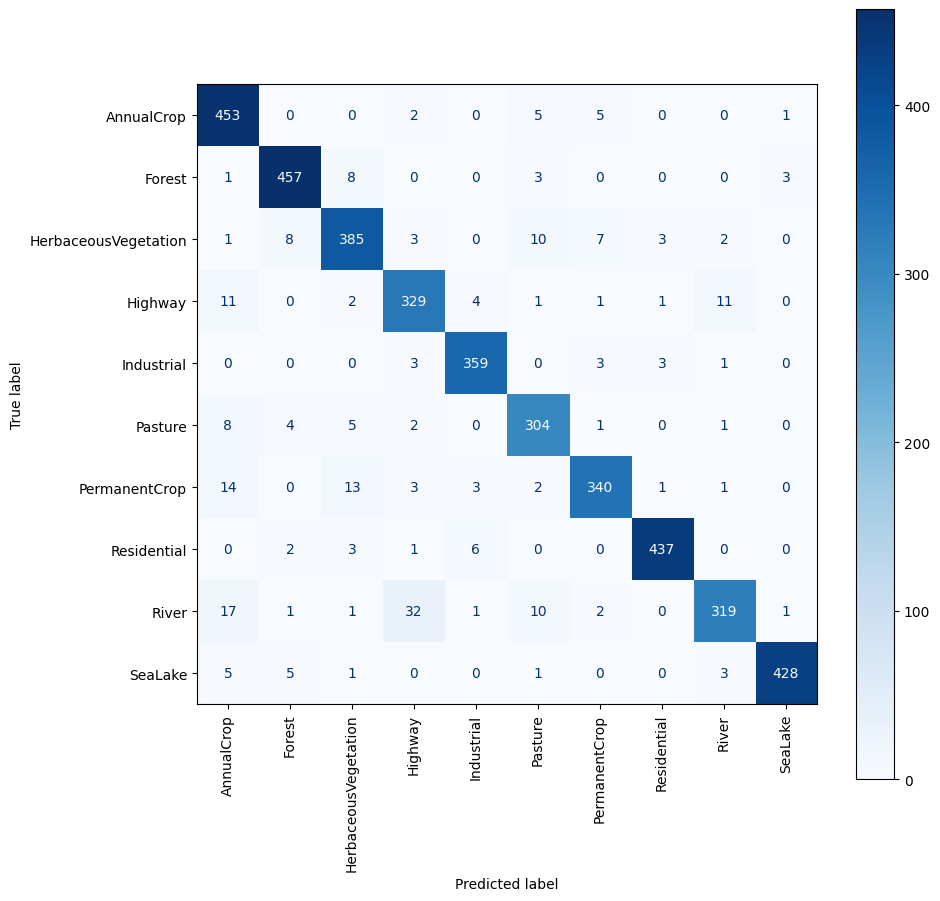

In [19]:
# Build your confusion matrix here
y_true_sat = []
y_pred_sat = []

for images, labels in test_ds_sat:
    preds = model_sat.predict(images, verbose=0)
    y_true_sat.extend(labels.numpy())
    y_pred_sat.extend(np.argmax(preds, axis=1)) # argmax for multi-class

cm_sat = confusion_matrix(y_true_sat, y_pred_sat)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sat, display_labels=class_names_sat)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.show()


*Your answer:* The classes that get mixed up the most is highways and rivers. These likely because they are both long strips of twists and turns.




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 0.9928 | 0.9398 |
| Test Accuracy | 0.9812 | 0.9385 |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.

2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*

1. The fire dataset is a closer match while the EuroSAT is a bigger mismatch. Looking at both the validation accuracy and the test acurracy's of both datasets the fire/smoke dataset was greater (higher by about 4%). This is likely because the EuroSAT is arieal photography which is a completely differnet perspective.

2. There is always room for improvement however, the fire/smoke dataset is mostly okay. However, EuroSAT would benefit from unfreezing the upper layers and fine tune them. Since its a completely different perspective for it, it would need more adjustment to its convolution filters.


---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

1. The fire dataset was definitely unbalanced with over three times as many fire images compared to the other non-fire images. This just meant that raw accuracy wasn't as reliable, which made the confusion matrix super important

2. Part 1 was binary classification (2 classes) so the output layer needed a single dense neuron, sigmoid, and binary_crossentropy loss. Part 2 was multi-class (10 total classes), which needed 10 dense neurons, softmax, and sparse_categorical_crossentropy loss.

3. A pretrained model's usefulness depends on how well the original training matches our context/task. The model we used was/is seemingly really good however, it was less effective with top-down satellite images compared to ground based fire images. Fire's validation accuracary was almost perfect while EuroSAT was at a 94% which is great but not like the other.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.